# 01 · Exploratory data analysis

**Goal:** understand the player-season table before building features and models.

One row = one player in one top-5 league season. Target = log of the player's first Transfermarkt
valuation on/after their last league game of the season (deadline 31 Oct). Built by `python -m src.data`.

To avoid peeking at the test set, every analysis below uses the **development seasons only
(2012/13–2024/25)**. The test season 2025/26 appears only in the row-count table.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.data import PLAYER_SEASON_PATH, TOP5_LEAGUES, season_label
from src.plot_style import LEAGUE_COLORS, POSITION_COLORS, SERIES, apply_style
from src.train import TEST_SEASON, BaselineModel, TARGET, cross_validate, expanding_window_folds

apply_style()
pd.set_option("display.float_format", "{:,.2f}".format)
FIG_DIR = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

full = pd.read_parquet(PLAYER_SEASON_PATH)
df = full[full["season"] < TEST_SEASON].copy()  # development seasons only
POSITIONS = ["GK", "DEF", "MID", "ATT"]
print(f"{len(full):,} rows in total, {len(df):,} in development seasons")

26,894 rows in total, 24,930 in development seasons


## Key findings

1. **Rows.** 36,669 top-5 league player-seasons → 27,436 with ≥450 league minutes → 26,894 with a valuation in the target window.
   Losses cluster in 2013/14 (Transfermarkt revalued less often then), 2019/20 (128 Bundesliga players: the covid-delayed season ended
   27 June 2020 and the next revaluation came in Nov 2020 / Feb 2021) and 2024/25 (87 players with no later valuation at all; their
   previous median value was EUR 1.5m vs 7.5m for kept players, i.e. mostly players who left the tracked leagues or retired).
2. **Target.** Median EUR 5.0m, 99th percentile EUR 75m, max EUR 200m. The raw scale is extremely right-skewed; log(value) is close to
   symmetric, so we regress on log(value).
3. **Valuation timing.** Median gap between last league game and target valuation is 13–24 days in recent seasons (90th pct 36–45 days);
   58% of targets are dated in June. Only 2–6% of targets per season are dated before the league's final matchday.
4. **Market drift (most important).** The median value rose from EUR 3.0m (2012/13) to EUR 7.5m (2024/25); the Premier League median
   from about EUR 4.5m to EUR 20m. A model that ignores time under-predicts every recent season (the baseline is ~35–38% too low) and the
   bias grows each year. Stage 3 must give the model a way to know the market level.
5. **Age.** Values are flat until ~26 and decline steadily after ~29. Young attackers carry the highest medians (a potential premium
   that performance stats cannot see). Defenders are the lowest-valued group at most ages; goalkeepers hold value longer.
6. **Signals.** League minutes correlate with value in every position (Spearman 0.33–0.48). Goals + assists per 90 matter for attackers
   (0.50) and midfielders (0.35), less for defenders (0.25) and barely for goalkeepers (0.10): goals/assists cannot measure defending or
   goalkeeping. Age is negatively correlated (−0.26 to −0.42).
7. **Missing values** are negligible (foot 0.8%, height 0.7%).
8. **Baseline** (median by position × age band): R² 0.07–0.09 on log value, median absolute error ~67%, only about one third of
   players within 50% of their market value. This is the bar the real models must clear.

## 1. Row counts after each filter

How many player-seasons survive each step (from `reports/filter_counts.csv`).

In [2]:
pd.read_csv(ROOT / "reports" / "filter_counts.csv", index_col=0)

,all top-5 league player-seasons,minutes >= 450,known position and birth date,valuation in target window
season,,,,
2012,2618,1934,1926,1915
2013,2618,1973,1966,1794
2014,2476,1898,1893,1871
2015,2639,1975,1972,1926
2016,2613,1975,1973,1967
2017,2566,1943,1941,1936
2018,2519,1956,1955,1951
2019,2609,1938,1938,1791
2020,2685,1979,1977,1976


## 2. The target: market value is heavily right-skewed

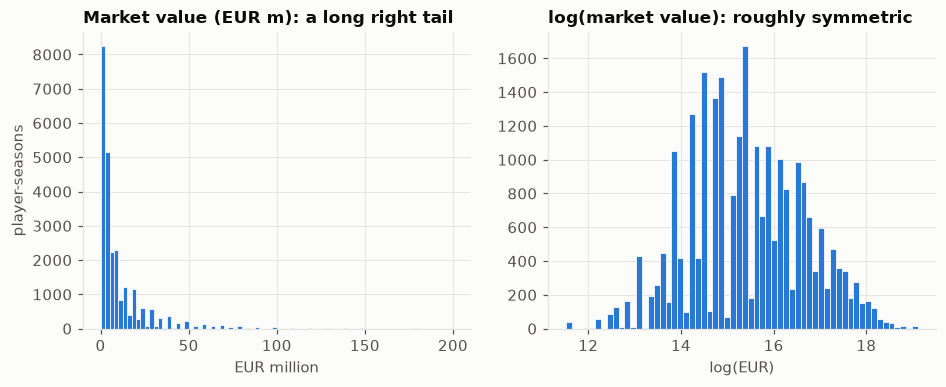

count         24,930
mean      10,599,958
std       15,615,328
min          100,000
10%        1,000,000
50%        5,000,000
90%       26,000,000
99%       75,000,000
max      200,000,000
Name: market_value_eur, dtype: str

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].hist(df["market_value_eur"] / 1e6, bins=80, color=SERIES[0], edgecolor="white", linewidth=0.5)
axes[0].set(title="Market value (EUR m): a long right tail", xlabel="EUR million", ylabel="player-seasons")
axes[1].hist(df["log_value"], bins=60, color=SERIES[0], edgecolor="white", linewidth=0.5)
axes[1].set(title="log(market value): roughly symmetric", xlabel="log(EUR)")
fig.savefig(FIG_DIR / "eda_target_distribution.png")
plt.show()
df["market_value_eur"].describe(percentiles=[0.1, 0.5, 0.9, 0.99]).apply(lambda v: f"{v:,.0f}")

## 3. Valuation timing

`days_since_last_game` = days between the player's last league game and the valuation used as the target.
`valuation_date` < league final matchday means the player's season ended early (injury, winter move).

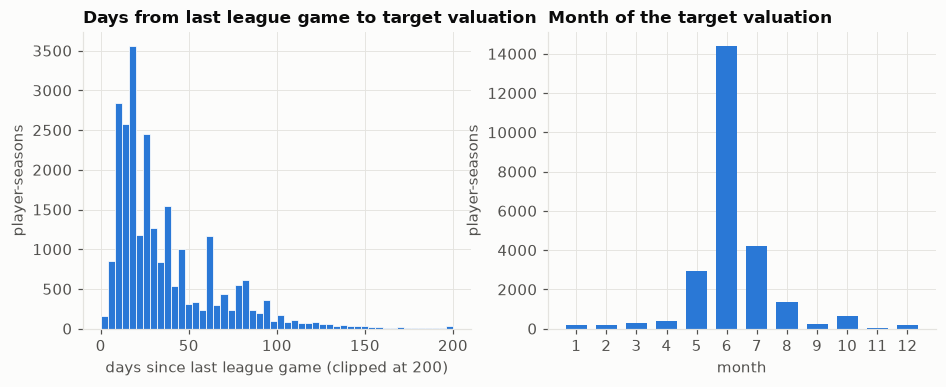

,median_days,p90_days,pct_before_final_matchday
season,,,
2012/13,38.00,59.00,3.13
2013/14,74.00,107.00,3.18
2014/15,39.00,72.00,3.21
2015/16,63.00,95.50,5.14
2016/17,26.00,55.00,4.27
2017/18,18.00,45.00,3.98
2018/19,24.00,53.00,2.77
2019/20,38.00,86.00,6.48
2020/21,18.00,37.50,2.73


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].hist(df["days_since_last_game"].clip(upper=200), bins=50, color=SERIES[0], edgecolor="white", linewidth=0.5)
axes[0].set(title="Days from last league game to target valuation", xlabel="days since last league game (clipped at 200)",
            ylabel="player-seasons")
months = df["valuation_date"].dt.month.value_counts().reindex(range(1, 13), fill_value=0)
axes[1].bar(months.index, months.values, color=SERIES[0], width=0.7)
axes[1].set(title="Month of the target valuation", xlabel="month", ylabel="player-seasons", xticks=range(1, 13))
fig.savefig(FIG_DIR / "eda_valuation_timing.png")
plt.show()

timing = df.assign(before_final_matchday=df["valuation_date"] < df["league_final_matchday"])
timing.groupby("season").agg(
    median_days=("days_since_last_game", "median"),
    p90_days=("days_since_last_game", lambda s: s.quantile(0.9)),
    pct_before_final_matchday=("before_final_matchday", lambda s: 100 * s.mean()),
).rename(index=season_label)

## 4. Market values drift upward over time

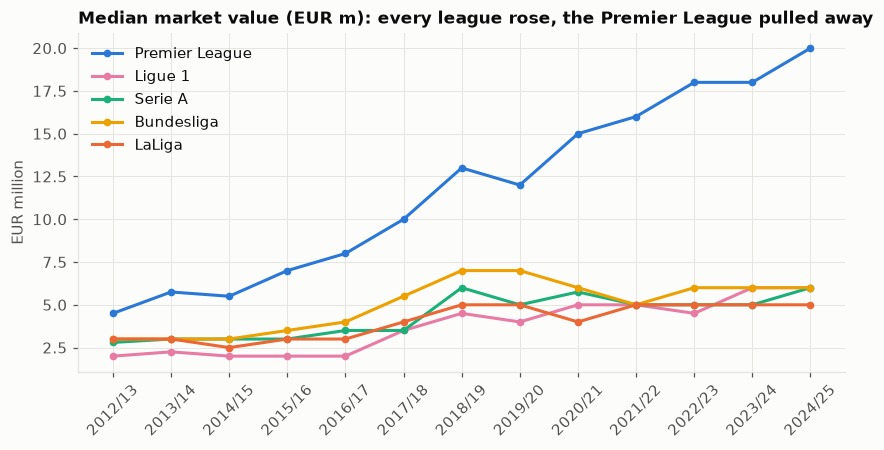

season,2012/13,2013/14,2014/15,2015/16,2016/17,2017/18,2018/19,2019/20,2020/21,2021/22,2022/23,2023/24,2024/25
median EUR m (all leagues),3.00,3.00,3.00,3.50,3.50,5.00,7.00,6.30,6.00,6.00,7.00,7.00,7.50


In [5]:
med = df.groupby(["season", "competition_id"])["market_value_eur"].median().unstack() / 1e6
fig, ax = plt.subplots(figsize=(9, 4))
for league in med.iloc[-1].sort_values(ascending=False).index:  # legend in the order of the latest value
    ax.plot(med.index, med[league], color=LEAGUE_COLORS[league], label=TOP5_LEAGUES[league], marker="o", markersize=4)
ax.set(title="Median market value (EUR m): every league rose, the Premier League pulled away", ylabel="EUR million",
       xticks=med.index, xticklabels=[season_label(s) for s in med.index])
ax.tick_params(axis="x", rotation=45)
ax.legend(loc="upper left")
fig.savefig(FIG_DIR / "eda_value_by_season.png")
plt.show()
overall = df.groupby("season")["market_value_eur"].median().rename(index=season_label) / 1e6
overall.to_frame("median EUR m (all leagues)").T

## 5. The age curve differs by position

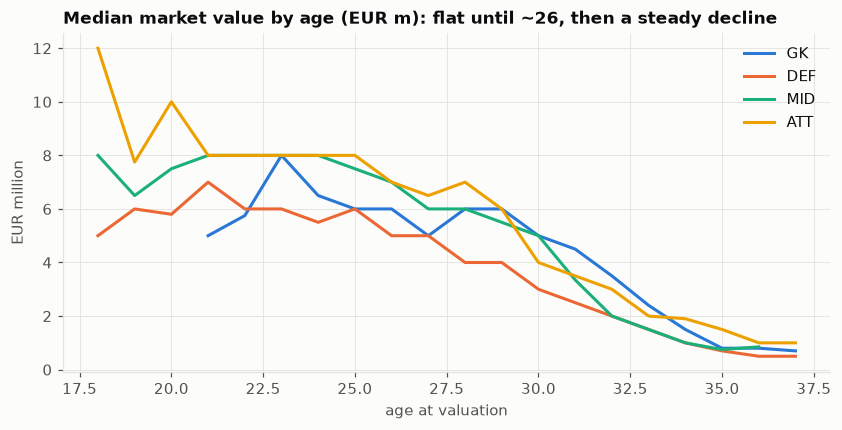

,count,mean,50%
position_group,,,
GK,"1,805.00",29.48,29.28
DEF,"9,259.00",27.39,27.18
MID,"7,556.00",27.03,26.85
ATT,"6,310.00",26.83,26.59


In [6]:
grouped = df.assign(age_int=df["age"].astype(int)).groupby(["age_int", "position_group"])["market_value_eur"]
curve = grouped.median().unstack() / 1e6
curve = curve.where(grouped.size().unstack() >= 30)  # hide noisy medians from fewer than 30 players
fig, ax = plt.subplots(figsize=(9, 4))
for pos in POSITIONS:
    ax.plot(curve.index, curve[pos], color=POSITION_COLORS[pos], label=pos)
ax.set(title="Median market value by age (EUR m): flat until ~26, then a steady decline",
       xlabel="age at valuation", ylabel="EUR million")
ax.legend(loc="upper right")
fig.savefig(FIG_DIR / "eda_value_by_age.png")
plt.show()
df.groupby("position_group")["age"].describe()[["count", "mean", "50%"]].reindex(POSITIONS)

## 6. Which raw signals relate to value?

Spearman rank correlation with log value, per position group. Per-90 stats here are a quick preview;
the real features are built in `src/features.py` (stage 3).

In [7]:
prev = df.assign(
    goals_p90=df["goals"] / df["minutes"] * 90,
    assists_p90=df["assists"] / df["minutes"] * 90,
    ga_p90=(df["goals"] + df["assists"]) / df["minutes"] * 90,
)
cols = ["minutes", "appearances", "goals_p90", "assists_p90", "ga_p90", "age", "height_in_cm"]
corr = pd.DataFrame({pos: prev[prev["position_group"] == pos][cols].corrwith(prev.loc[prev["position_group"] == pos, "log_value"],
                                                                          method="spearman")
                     for pos in POSITIONS})
corr

,GK,DEF,MID,ATT
minutes,0.48,0.33,0.36,0.44
appearances,0.48,0.34,0.37,0.37
goals_p90,0.03,0.24,0.31,0.42
assists_p90,0.09,0.19,0.30,0.32
ga_p90,0.10,0.25,0.35,0.50
age,-0.42,-0.36,-0.31,-0.26
height_in_cm,0.20,0.09,0.03,-0.03


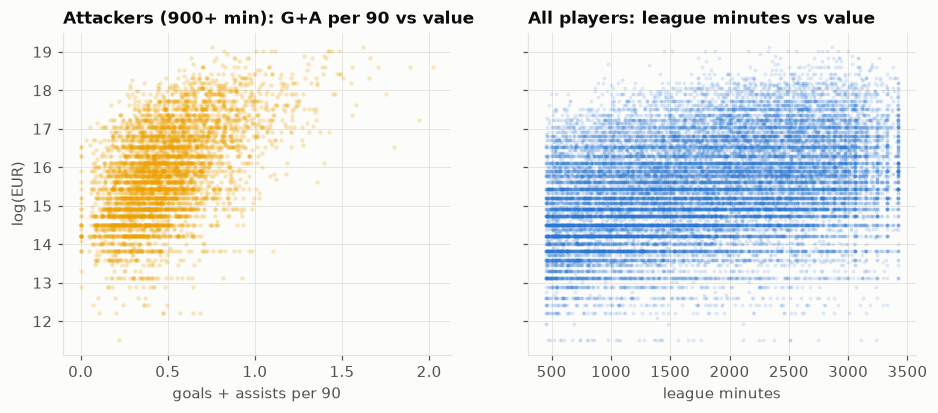

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True)
att = prev[(prev["position_group"] == "ATT") & (prev["minutes"] >= 900)]
axes[0].scatter(att["ga_p90"], att["log_value"], s=8, alpha=0.25, color=POSITION_COLORS["ATT"], linewidths=0)
axes[0].set(title="Attackers (900+ min): G+A per 90 vs value", xlabel="goals + assists per 90", ylabel="log(EUR)")
axes[1].scatter(prev["minutes"], prev["log_value"], s=6, alpha=0.15, color=SERIES[0], linewidths=0)
axes[1].set(title="All players: league minutes vs value", xlabel="league minutes")
fig.savefig(FIG_DIR / "eda_signals.png")
plt.show()

## 7. Missing values (development seasons)

In [9]:
miss = df.isna().mean().mul(100).round(2)
miss[miss > 0].to_frame("% missing")

,% missing
foot,0.83
height_in_cm,0.73
country_of_citizenship,0.65


## 8. Baseline: median log value by position × age band

Expanding-window CV: each fold trains on all seasons before the validation season.
`mean_residual` = mean of (predicted − actual) log value; negative = the model under-predicts.

In [10]:
cv = cross_validate(BaselineModel, df)
bias = []
for season, tr, va in expanding_window_folds(df["season"]):
    model = BaselineModel().fit(df[tr], df.loc[tr, TARGET])
    bias.append(np.mean(model.predict(df[va]) - df.loc[va, TARGET]))
cv["mean_residual"] = bias
cv["typical_ratio_pred_to_actual"] = np.exp(cv["mean_residual"])
cv

,valid_season,n_train,n_valid,rmse_log,r2_log,mae_eur,median_ape,within_25,within_50,mean_residual,typical_ratio_pred_to_actual
0,2021/22,17127,1979,1.16,0.08,"9,217,504.77",0.67,0.17,0.35,-0.42,0.66
1,2022/23,19106,2006,1.16,0.09,"9,878,550.75",0.67,0.17,0.34,-0.44,0.64
2,2023/24,21112,1953,1.16,0.08,"10,605,906.23",0.67,0.17,0.34,-0.45,0.64
3,2024/25,23065,1865,1.19,0.07,"11,404,308.46",0.68,0.16,0.32,-0.48,0.62
